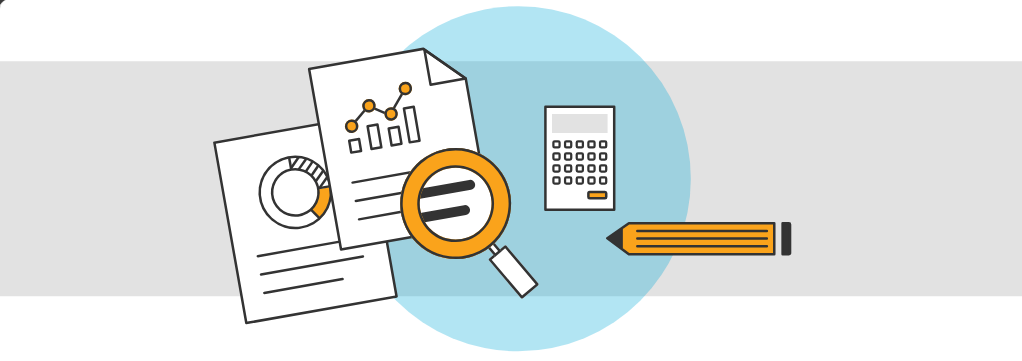

In [ ]:
# Required libraries
library(dplyr)
library(ggplot2)
library(lubridate)

In [2]:
# 1. Create a virtual dataset
set.seed(123)
sales_data <- data.frame(
  date = sample(seq(as.Date('2025-01-01'), as.Date('2025-12-31'), by="day"), 1000,replace = TRUE),
  product = sample(c("product_A", "product_B", "product_C"), 1000, replace = TRUE),
  quantity = sample(1:10, 1000, replace = TRUE),
  unit_price = round(runif(1000, 10, 100), 2)
)

In [3]:
# Inserting random NA values for demonstration
sales_data$quantity[sample(1:nrow(sales_data), 30)] <- NA
sales_data$unit_price[sample(1:nrow(sales_data), 20)] <- NA

In [ ]:
# Data Cleansing: Dealing with NA values
# We choose to remove lines with NA in quantity or price (since we cannot calculate revenue)
cleaned_data <- sales_data %>%
  filter(!is.na(quantity) & !is.na(unit_price))

In [5]:
# Add a variable for revenue per sale
cleaned_data <- cleaned_data %>%
  mutate(revenue = quantity * unit_price)

# Calculation of total monthly revenue
monthly_revenue <- cleaned_data %>%
  mutate(month = floor_date(date, "month")) %>%  # Grouping by month
  group_by(month) %>%
  summarise(total_revenue = sum(revenue), .groups = 'drop') %>%
  arrange(month)

# Show results
print("Monthly Revenue:")
print(monthly_revenue)

[1] "Monthly Revenue:"


# A tibble: 12 × 2
   month      total_revenue
   <date>             <dbl>
 1 2025-01-01        23808.
 2 2025-02-01        24992 
 3 2025-03-01        24902.
 4 2025-04-01        23294.
 5 2025-05-01        20563.
 6 2025-06-01        27472.
 7 2025-07-01        24868.
 8 2025-08-01        24396.
 9 2025-09-01        21957.
10 2025-10-01        25670.
11 2025-11-01        21825.
12 2025-12-01        21356.


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


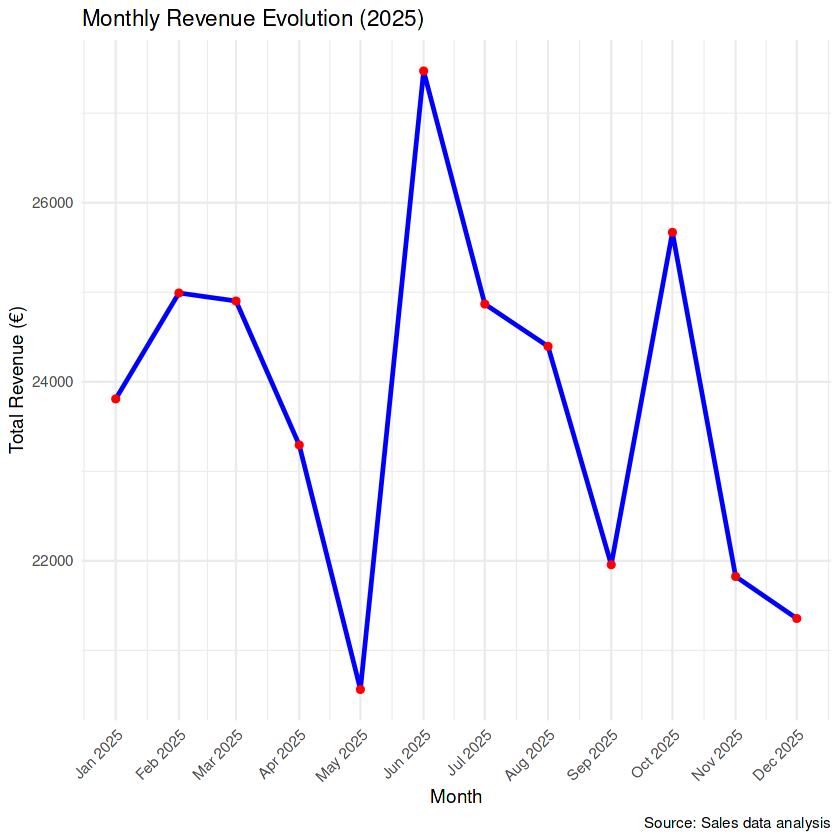

In [6]:
# Creating a graph with ggplot2
ggplot(monthly_revenue, aes(x = month, y = total_revenue)) +
  geom_line(color = "blue", size = 1) +
  geom_point(color = "red") +
  labs(
    title = "Monthly Revenue Evolution (2025)",
    x = "Month",
    y = "Total Revenue (€)",
    caption = "Source: Sales data analysis"
  ) +
  theme_minimal() +
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Δημιουργία δεδομένων
Τα δεδομένα δημιουργήθηκαν τυχαία σε χρονική περίοδο ενός έτους με 1000 δείγματα.
Κάθε στοιχείο είναι μια τυχαία επιλογή από το διάνυσμα c("Product Α", "Product Β", "Product Γ"). Στη συνέχεια δημιουργήθηκε ένα διάνυσμα 1000 τυχαίων ακεραίων, όπου κάθε αριθμός είναι μεταξύ 1 έως 10 και αντιστοιχεί στην ποσότητα ενός προϊόντος σε μια συναλλαγή.
Τέλος δημιουργήθηκαν 1000 τυχαίοι συνεχείς αριθμοί από μια ομοιόμορφη κατανομή (uniform distribution) μεταξύ 10 και 100, στρογγυλοποιημένοι σε 2 δεκαδικά ψηφία, προσομοιώνοντας έτσι μια τιμή μονάδας σε ευρώ.

# Καθαρισμός δεδομένων
Ο καθαρισμός των δεδομένων εξασφάλισε αξιόπιστους υπολογισμούς. Προτιμήθηκε η αφαίρεση των null values καθώς ήταν λίγα σε σχέση με το μέγεθος του δειγματος. Σε διαφορετική περίπτωση θα μπορουσαμε να αντικαταστήσουμε τα nulls με την μέση τιμή της αντίστοιχης στήλης.

# Ερμηνεία αποτελεσμάτων
Η ανάλυση (τελικό γράφημα) δείχνει την εξέλιξη του τζίρου ανά μήνα για το έτος 2025. 
1. Παρατηρείται μια συνεχής αστάθεια στις μηνιαίες πωλήσεις.
2. Μεγαλη πτώση τον Μάιο (minimum value) και ραγδαία αύξηση τον επόμενο μήνα (max value).
3. Παρόμοιο μοτίβο παρατηρείται και τους μήνες Σεπτέμβριο και Οκτώβριο.
4. Υποθέτω πως η εταιρία μετά απο μήνες με μεγαλη πτώση ακολουθεί κάποια στρατιγική άμεσης αύξησης του τζίρου, ίσως με μεγαλύτερες εκπτώσεις, περισσότερες προσφορές και έντονες διαφημιστικές δράσεις.
5. Το έτος ξεκίνησε τον Ιανουάριο σε γενικές γραμμές κοντά στο μέσο όρο, έκλεισε όμως το Δεκέμβριο σε πολύ χαμηλά επίπεδα με τη δεύτερη χαμηλότερη ετήσια τιμή τζίρου.



In [7]:
# ** EXTRA ANALYSIS **

# Calculation of total revenue and number of sales per product
product_summary <- cleaned_data %>%
  group_by(product) %>%
  summarise(
    total_revenue = sum(revenue),
    num_orders = n()
  ) %>%
  arrange(desc(total_revenue))

# Show results
print("Products by revenue and number of orders:")
print(product_summary)

# Product with the most revenue
top_revenue <- product_summary[1, ]
cat("\nProduct with the most revenue:\n")
print(top_revenue)

# Best-selling product (orders)
top_orders <- product_summary %>% arrange(desc(num_orders)) %>% slice(1)
cat("\nBest-selling product (number):\n")
print(top_orders)

[1] "Products by revenue and number of orders:"


# A tibble: 3 × 3
  product   total_revenue num_orders
  <chr>             <dbl>      <int>
1 product_A        99244.        315
2 product_B        94258.        308
3 product_C        91600.        327



Product with the most revenue:


# A tibble: 1 × 3
  product   total_revenue num_orders
  <chr>             <dbl>      <int>
1 product_A        99244.        315



Best-selling product (number):


# A tibble: 1 × 3
  product   total_revenue num_orders
  <chr>             <dbl>      <int>
1 product_C        91600.        327


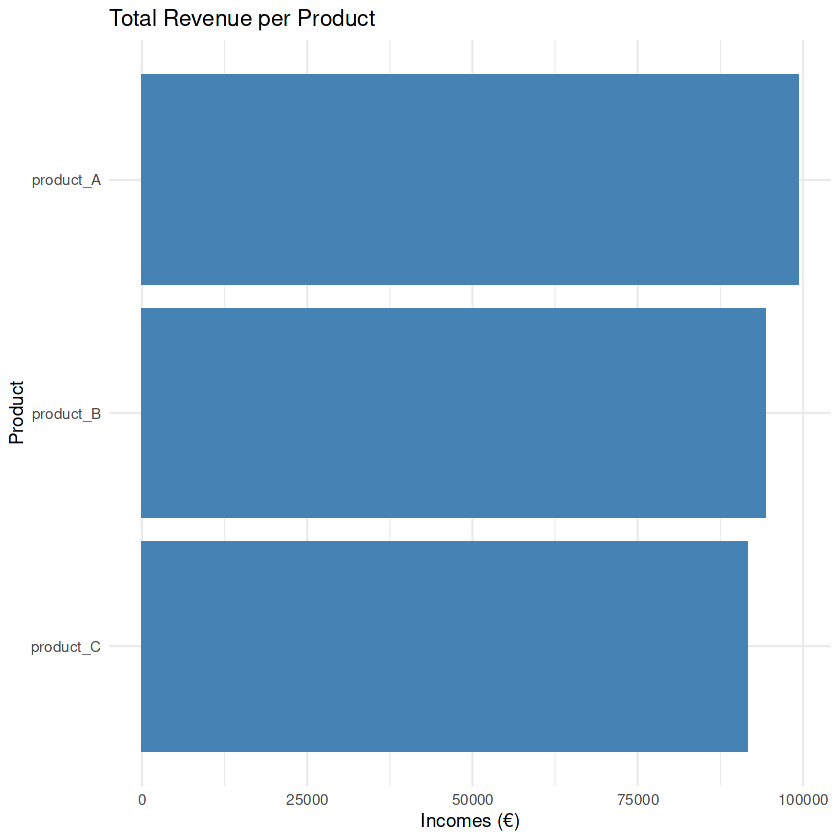

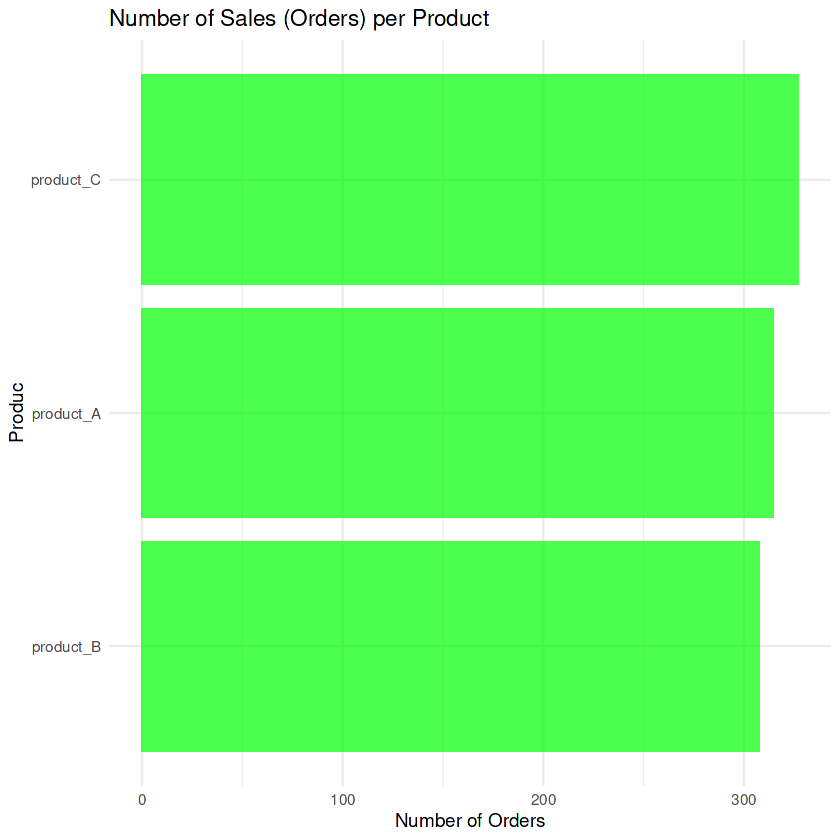

In [8]:
# Revenue per product chart
ggplot(product_summary, aes(x = reorder(product, total_revenue), y = total_revenue)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Total Revenue per Product", x = "Product", y = "Incomes (€)") +
  theme_minimal()

# Graph for number of orders per product
ggplot(product_summary, aes(x = reorder(product, num_orders), y = num_orders)) +
  geom_col(fill = "green", alpha = 0.7) +
  coord_flip() +
  labs(title = "Number of Sales (Orders) per Product", x = "Produc", y = "Number of Orders") +
  theme_minimal()